# 🚢 Titanic Dataset — Exploratory Data Analysis

#  Project Overview

This project performs an Exploratory Data Analysis (EDA) on the Titanic dataset.

The main goal is to explore the dataset, identify patterns in passenger survival,
and understand how factors such as gender, passenger class, age, family size,
and embarkation point are associated with survival.

#  Analytical Questions

- What percentage of passengers survived?
- Does gender affect survival?
- Does passenger class affect survival?
- Is age associated with survival?
- Does family size affect survival?
- Does the combination of gender and passenger class affect survival?
- Which passenger groups had the highest and lowest survival rates?

#  Tools & Libraries

- Python
- Pandas
- Matplotlib
- Seaborn

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  1. Data Loading

In this section, we will load the Titanic dataset and perform an initial inspection of the data.

The main objectives are to:
- Load the dataset.
- Display the first and last rows.
- Check the dataset dimensions.
- Understand the column names and data types.

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


# 🔍 2. Initial Data Exploration

In this section, we will examine the structure and statistical characteristics of the dataset.

The main objectives are to:
- Understand the number of rows and columns.
- Identify the data types.
- Review basic statistical information.
- Identify missing values.
- Check for duplicate records.

In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [37]:
print(df.isnull().sum())

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Embarked          0
FamilySize        0
FamilyCategory    0
dtype: int64


In [10]:
df.isnull().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [11]:
df.duplicated().sum()

np.int64(0)

#  3. Data Cleaning

In this section, we will prepare the dataset for analysis by handling missing values and removing columns that are not suitable for further analysis.

The main steps include:
- Handling missing values.
- Removing the Cabin column due to its high percentage of missing values.
- Filling missing Age values using the median.
- Filling missing Embarked values using the mode.
- Verifying the dataset after cleaning.

### ------------------------------------------------------

In [12]:
numeric_cols = df.select_dtypes(include="number").columns
category_cols = df.select_dtypes(include="object").columns

C:\Users\O.R.G\AppData\Local\Temp\ipykernel_11396\2379004033.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_cols = df.select_dtypes(include="object").columns


##  Handling Cabin

The Cabin column contains a large number of missing values.
Therefore, it will be removed because reliable imputation would be difficult.

In [34]:
df = df.drop(columns=["Cabin"])

KeyError: "['Cabin'] not found in axis"

##  Handling Embarked

The Embarked column contains a small number of missing values.
Since Embarked is a categorical variable, the mode will be used to fill the missing values.

In [35]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

## Handling Age

The Age column contains missing values.
The median will be used to fill the missing values because it is less sensitive to extreme values than the mean.

In [36]:
print("Mean:", df["Age"].mean())
print("Median:", df["Age"].median())

Mean: 29.36158249158249
Median: 28.0


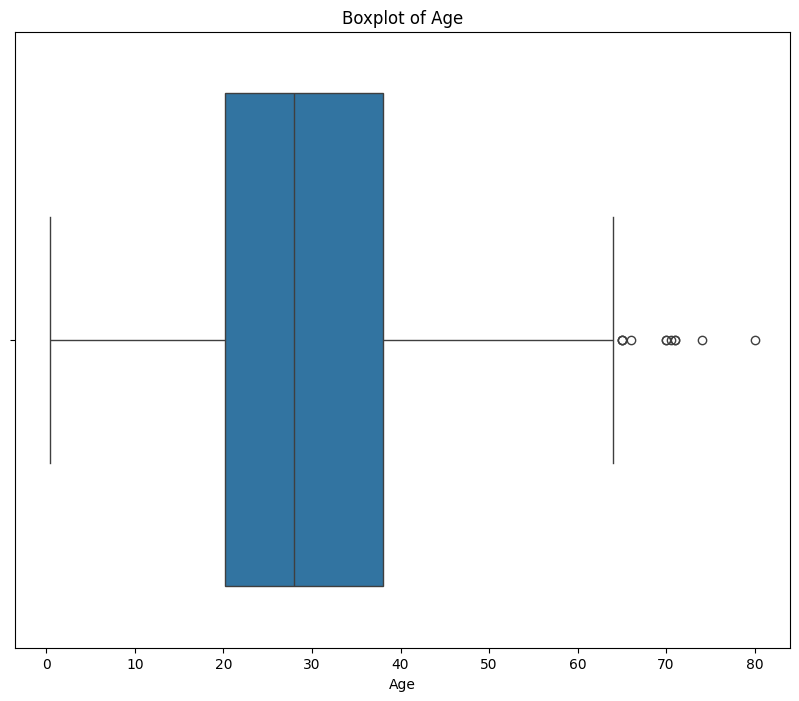

In [16]:

plt.figure(figsize=(10, 8))
sns.boxplot(
    data=df,
    x="Age"
)
plt.title('Boxplot of Age')
plt.show()

In [17]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower)
print("Upper:", upper)

Q1: 20.125
Q3: 38.0
IQR: 17.875
Lower: -6.6875
Upper: 64.8125


In [18]:
outliers = df[
    (df["Age"] < lower) |
    (df["Age"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 11


In [19]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [20]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

### Cleaning Summary

- The `Cabin` column was removed because it contains a high proportion of missing values.
- Missing `Age` values were replaced using the median age.
- Missing `Embarked` values were replaced using the most frequent value (mode).
- Duplicate records were checked and no duplicates were found.
- The dataset was validated after cleaning to ensure that missing values were handled correctly.

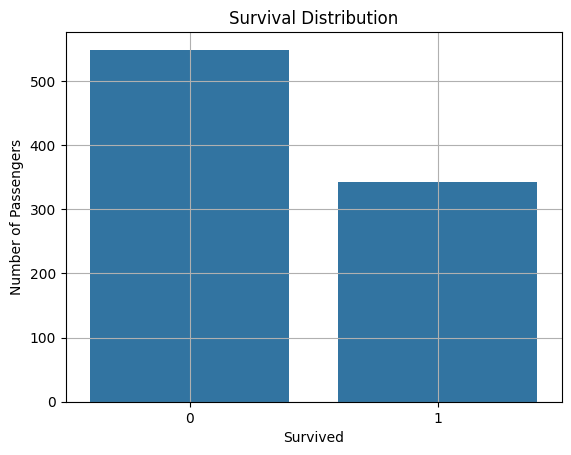

In [21]:
sns.countplot(
    data=df,
    x="Survived"
)
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.grid(True,alpha=1)
plt.show()

# Insight

Most passengers did not survive the Titanic disaster.
Out of 891 passengers, 549 did not survive, while 342 passengers survived.
This means that approximately 38.4% of the passengers survived.

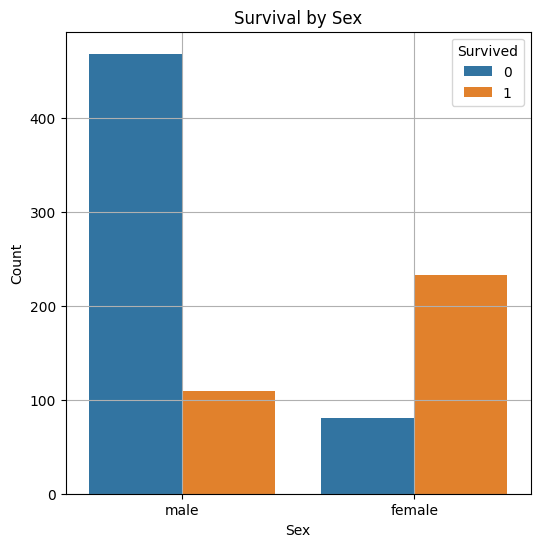

In [22]:
plt.figure(figsize=(6,6))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.grid(True,alpha=1)

plt.show()

# Insight

The survival outcome was strongly associated with sex.
Most male passengers did not survive, while female passengers had a much higher proportion of survivors.
This suggests that female passengers were more likely to survive than male passengers.

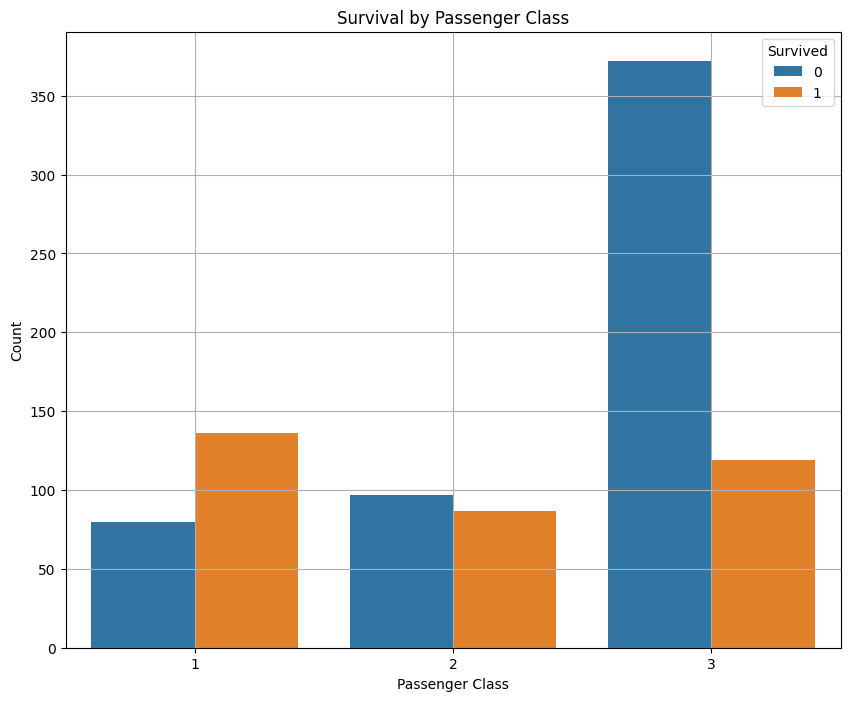

In [23]:
plt.figure(figsize=(10,8))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.grid(True,alpha=1)

plt.show()

# Insight

Survival varied considerably across passenger classes.
First-class passengers had the highest survival rate, while third-class passengers had the lowest survival rate.
This suggests a strong association between passenger class and survival.

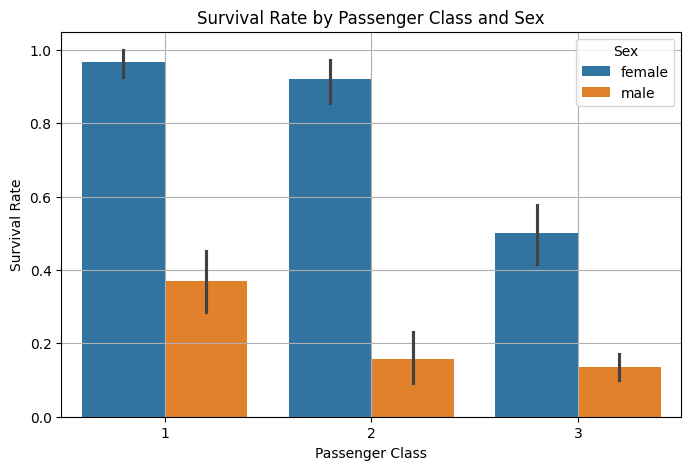

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.grid(True,alpha=1)

plt.show()

# Insight

Female passengers had a substantially higher survival rate than male passengers across all passenger classes.
First-class females had the highest survival rate, while third-class males had the lowest survival rate.
This indicates that both sex and passenger class were strongly associated with survival outcomes.

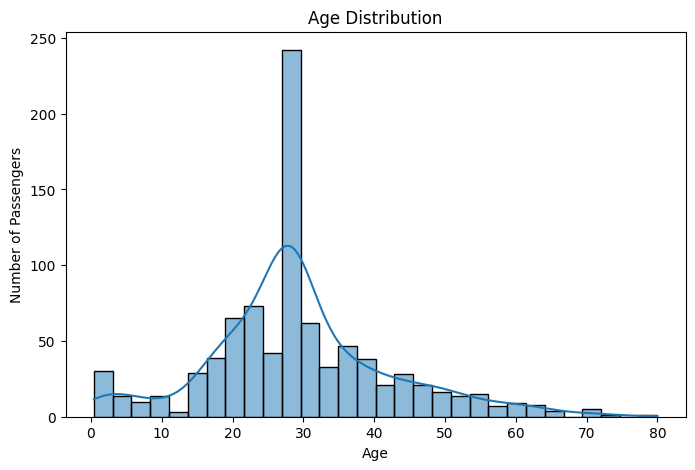

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

# Insight

Passenger ages ranged from young children to elderly passengers, with most passengers concentrated around young and middle adulthood.
The distribution is slightly right-skewed, with fewer passengers at older ages.
The mean age was approximately 29.7 years, while the median was 28 years.

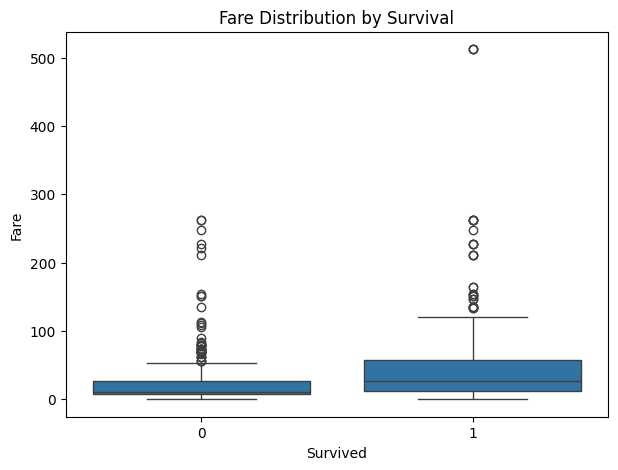

In [26]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare"
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

# Insight

Passengers who survived generally paid higher fares than passengers who did not survive.
The median fare for survivors was higher than the median fare for non-survivors.
This suggests that higher fares were associated with a higher probability of survival.

### ---------------------------------------------------------------------------

##  5.7 Family Size and Survival

This analysis examines survival rates across different family-size categories.

### Objective
To determine whether family size was associated with survival.

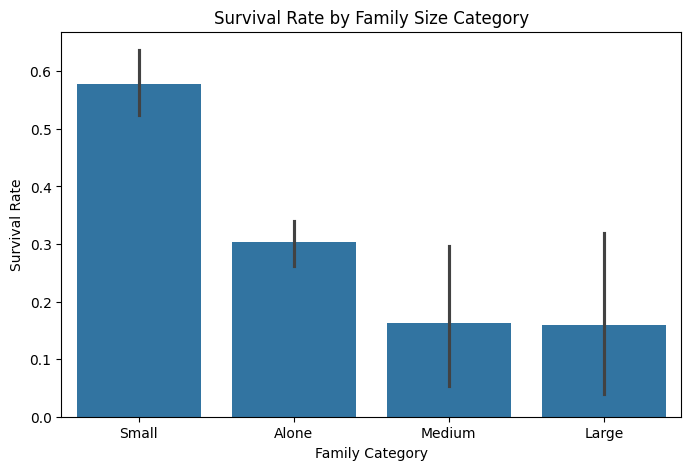

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="FamilyCategory",
    y="Survived"
)

plt.title("Survival Rate by Family Size Category")
plt.xlabel("Family Category")
plt.ylabel("Survival Rate")

plt.show()

# Insight

Passengers traveling in small families had the highest survival rate at approximately 57.9%.
Passengers traveling alone had a survival rate of approximately 30.4%, while medium and large families had much lower survival rates.
This suggests that family size was associated with survival, although other factors such as sex and passenger class may also have influenced the outcome.

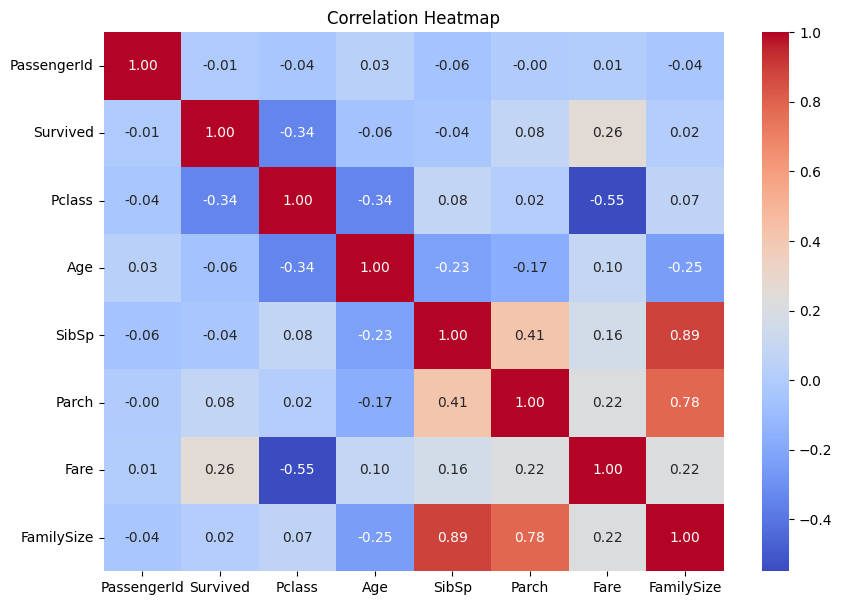

In [29]:
plt.figure(figsize=(10, 7))

numeric_cols = df.select_dtypes(include="number")

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Insight

The correlation heatmap shows that Pclass has a negative relationship with Survived, while Fare has a positive relationship with Survived.
FamilySize has a relatively weak relationship with survival.
The heatmap also shows a strong relationship between SibSp, Parch, and FamilySize because FamilySize was derived from these variables.
Correlation indicates association and does not necessarily imply causation.

In [39]:
X = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')
y = df['Survived']

In [41]:
X = pd.get_dummies(X,
                    drop_first=True)

In [51]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)


preds = model.predict(X_test_scaled)


print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1-Score :", f1_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

Accuracy : 0.8156424581005587
Precision: 0.8
Recall   : 0.6956521739130435
F1-Score : 0.7441860465116279
Confusion Matrix:
 [[98 12]
 [21 48]]


In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

preds = model.predict(X_test_scaled)
print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1-Score :", f1_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

Accuracy : 0.8212290502793296
Precision: 0.8032786885245902
Recall   : 0.7101449275362319
F1-Score : 0.7538461538461538
Confusion Matrix:
 [[98 12]
 [20 49]]


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

preds = model.predict(x_test)
print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1-Score :", f1_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

=== Random Forest ===
Accuracy : 0.8212290502793296
Precision: 0.7846153846153846
Recall   : 0.7391304347826086
F1-Score : 0.7611940298507462
Confusion Matrix:
 [[96 14]
 [18 51]]


## 6. Model Evaluation & Conclusion

* **Logistic Regression:** Achieved **81.56%** accuracy with high precision (0.8000), providing a solid linear baseline.
* **K-Nearest Neighbors (KNN):** Achieved **82.12%** accuracy on scaled features with a balanced F1-Score of 0.7538.
* **Random Forest:** Delivered the best overall performance with **82.12%** accuracy, achieving the highest **Recall (0.7391)** and **F1-Score (0.7611)** on raw features.

**Final Decision:** Random Forest is selected as the top-performing model for its superior recall and ability to minimize false negatives in predicting passenger survival.